# Create Mooring X Array 


In [2]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [7]:
#For Each Mooring Site, create XArray 
S1P1_ds= xr.open_dataset('/home/jovyan/Society_of_Bouy_Cowboys/Data/NET_CDF/S1P1.nc')

S1P2_ds= xr.open_dataset('/home/jovyan/Society_of_Bouy_Cowboys/Data/NET_CDF/S1P2.nc')

S1P3_ds= xr.open_dataset('/home/jovyan/Society_of_Bouy_Cowboys/Data/NET_CDF/S1P3.nc')

S1P4_ds= xr.open_dataset('/home/jovyan/Society_of_Bouy_Cowboys/Data/NET_CDF/S1P4.nc')

S1A1_ds= xr.open_dataset('/home/jovyan/Society_of_Bouy_Cowboys/Data/NET_CDF/S1A1.nc')

ds_list = [S1P1_ds, S1P2_ds, S1P3_ds, S1A1_ds]


In [9]:
xr.concat(ds_list, dim='source')

<xarray.Dataset> Size: 43MB
Dimensions:         (source: 4, time: 2604, freq: 84)
Coordinates:
  * time            (time) datetime64[ns] 21kB 2019-11-09T07:27:07.000002816 ...
  * freq            (freq) float64 672B 0.009766 0.009766 ... 0.4902 0.4902
Dimensions without coordinates: source
Data variables: (12/13)
    lat_lagrangian  (source, time) float64 83kB nan 70.35 nan ... nan 70.49
    lon_lagrangian  (source, time) float64 83kB nan -162.1 nan ... nan -162.3
    watertemp       (source, time) float64 83kB nan 20.76 nan ... nan nan nan
    sigwaveheight   (source, time) float64 83kB nan nan nan ... 1.709 nan 1.962
    peakwaveperiod  (source, time) float64 83kB nan nan nan ... 7.211 nan 7.211
    peakwavedirT    (source, time) float64 83kB nan 9.999e+03 nan ... nan nan
    ...              ...
    a1              (source, freq, time) float64 7MB nan nan nan ... nan nan nan
    b1              (source, freq, time) float64 7MB nan nan nan ... nan nan nan
    a2              (source, freq, time) float64 7MB nan nan nan ... nan nan nan
    b2              (source, freq, time) float64 7MB nan nan nan ... nan nan nan
    check           (source, freq, time) float64 7MB nan nan nan ... nan nan nan
    depth           (source, time) float64 83kB nan 13.0 nan nan ... nan nan nan

In [13]:
S1P3_ds.time

<xarray.DataArray 'time' (time: 749)> Size: 6kB
array(['2019-11-09T07:30:50.000000256', '2019-11-09T08:00:50.000003840',
       '2019-11-09T08:30:49.999996928', ..., '2019-11-24T20:30:49.999996928',
       '2019-11-24T21:00:50.000000256', '2019-11-24T21:30:50.000003840'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 2019-11-09T07:30:50.000000256 ... 2019...
Attributes:
    long_name:      time
    standard_name:  time

In [15]:
common_time = pd.date_range(
    S1A1_ds.time.min().values,
    S1A1_ds.time.max().values,
    freq="30min"
)

S1A1_ds_halfhour = S1A1_ds.interp(time=common_time)
S1A1_ds_halfhour

<xarray.Dataset> Size: 1MB
Dimensions:         (time: 725, freq: 42)
Coordinates:
  * freq            (freq) float64 336B 0.009766 0.02148 ... 0.4785 0.4902
  * time            (time) datetime64[ns] 6kB 2019-11-09T20:17:13.250987264 ....
Data variables:
    lat_lagrangian  (time) float64 6kB 70.49 70.49 70.49 ... 70.49 70.49 70.49
    lon_lagrangian  (time) float64 6kB -162.3 -162.3 -162.3 ... -162.3 -162.3
    sigwaveheight   (time) float64 6kB 0.656 0.6704 0.6849 ... 1.709 1.836 1.962
    peakwaveperiod  (time) float64 6kB 7.877 7.544 7.211 ... 7.211 7.211 7.211
    peakwavedirT    (time) float64 6kB nan nan nan nan nan ... nan nan nan nan
    energy          (freq, time) float64 244kB 0.0 0.0 0.0 ... 0.03249 0.04849
    a1              (freq, time) float64 244kB nan nan nan nan ... nan nan nan
    b1              (freq, time) float64 244kB nan nan nan nan ... nan nan nan
    a2              (freq, time) float64 244kB nan nan nan nan ... nan nan nan
    b2              (freq, time) float64 244kB nan nan nan nan ... nan nan nan
    check           (freq, time) float64 244kB nan nan nan nan ... nan nan nan

In [19]:
ds_list = [S1P1_ds, S1P2_ds, S1P3_ds, S1A1_ds_halfhour]
labels = ["S1P1", "S1P2", "S1P3", "S1A1"]

# common 30-minute grid over the overlapping time range
tmin = max(pd.Timestamp(ds.time.min().values).ceil("30min") for ds in ds_list)
tmax = min(pd.Timestamp(ds.time.max().values).floor("30min") for ds in ds_list)
common_time = pd.date_range(tmin, tmax, freq="30min")

# snap each dataset to the shared grid
aligned = [
    ds.reindex(time=common_time, method="nearest", tolerance=pd.Timedelta("15min"))
    for ds in ds_list
]

# combine
ds_out = xr.concat(
    aligned,
    dim=xr.DataArray(labels, dims="source", name="source")
)


In [20]:
ds_out

<xarray.Dataset> Size: 12MB
Dimensions:         (source: 4, time: 718, freq: 84)
Coordinates:
  * time            (time) datetime64[ns] 6kB 2019-11-09T20:30:00 ... 2019-11...
  * freq            (freq) float64 672B 0.009766 0.009766 ... 0.4902 0.4902
  * source          (source) <U4 64B 'S1P1' 'S1P2' 'S1P3' 'S1A1'
Data variables: (12/13)
    lat_lagrangian  (source, time) float64 23kB 70.35 70.35 ... 70.49 70.49
    lon_lagrangian  (source, time) float64 23kB -162.1 -162.1 ... -162.3 -162.3
    watertemp       (source, time) float64 23kB 15.82 15.73 14.57 ... nan nan
    sigwaveheight   (source, time) float64 23kB nan nan nan ... 1.89 1.827 1.823
    peakwaveperiod  (source, time) float64 23kB nan nan nan ... 7.211 7.544
    peakwavedirT    (source, time) float64 23kB nan nan nan nan ... nan nan nan
    ...              ...
    a1              (source, freq, time) float64 2MB nan nan nan ... nan nan nan
    b1              (source, freq, time) float64 2MB nan nan nan ... nan nan nan
    a2              (source, freq, time) float64 2MB nan nan nan ... nan nan nan
    b2              (source, freq, time) float64 2MB nan nan nan ... nan nan nan
    check           (source, freq, time) float64 2MB nan nan nan ... nan nan nan
    depth           (source, time) float64 23kB 13.0 13.0 13.0 ... nan nan nan

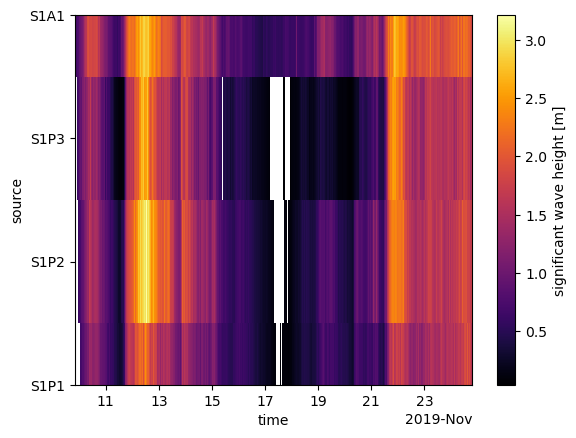

In [21]:
ds_waves= ds_out['sigwaveheight']

f, ax =plt.subplots()

ds_waves.plot(x= 'time', y='source', cmap= 'inferno')

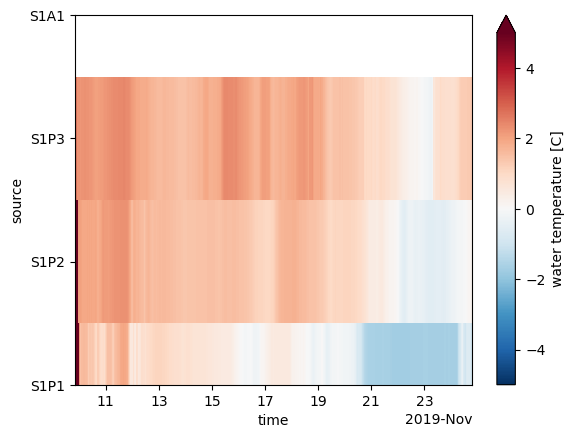

In [26]:
ds_waves= ds_out['watertemp']

f, ax =plt.subplots()

ds_waves.plot(x= 'time', y='source', vmin=-5, vmax=5, cmap= 'RdBu_r')